<a href="https://colab.research.google.com/github/98299/Api-cards/blob/main/Capstone_module2_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1. Project Summary

"""The objective of this project is to analyze customer financial and credit behavior data
to understand the key factors affecting an individual's credit score. Credit score
assessment plays a crucial role in loan approvals, risk management, and personalized
financial recommendations.

Using Exploratory Data Analysis (EDA), we identify trends, correlations, and patterns
between income, credit usage, payment behavior, and outstanding debt. These insights
can help Paisabazaar improve its creditworthiness assessment process and minimize
default risks."""


In [ ]:
#2. Business Context

"""Paisabazaar is a financial services platform that assists users in comparing and
applying for loans, credit cards, and other financial products. A key component of
its service is evaluating the creditworthiness of customers.

Credit score classification helps:
- Reduce loan default risk
- Improve approval accuracy
- Provide personalized financial advice
- Enhance customer trust

By analyzing customer financial data, Paisabazaar can make data-driven decisions
and improve overall customer satisfaction."""


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("/content/dataset (2).csv")

In [ ]:
df.tail(11)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
99989,155615,34304,6,Sarah McBridec,28.0,31350942.0,Architect,20002.88,1929.906667,10.0,...,Bad,3571.70,33.359987,73.0,Yes,60.964772,34.662906,Low_spent_Small_value_payments,307.659291,Standard
99990,155616,34304,7,Sarah McBridec,28.0,31350942.0,Architect,20002.88,1929.906667,10.0,...,Bad,3571.70,25.123535,74.0,Yes,60.964772,34.662906,Low_spent_Large_value_payments,228.750392,Standard
99991,155617,34304,8,Sarah McBridec,29.0,31350942.0,Architect,20002.88,1929.906667,10.0,...,Bad,3571.70,37.140784,75.0,Yes,60.964772,34.662906,High_spent_Large_value_payments,337.362988,Standard
99992,155622,37932,1,Nicks,24.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,32.991333,375.0,No,35.104023,24.028477,Low_spent_Small_value_payments,189.641080,Poor
99993,155623,37932,2,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,29.135447,376.0,No,35.104023,24.028477,Low_spent_Medium_value_payments,400.104466,Standard
99994,155624,37932,3,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,39.323569,377.0,No,35.104023,24.028477,High_spent_Medium_value_payments,410.256158,Poor
99995,155625,37932,4,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,34.663572,378.0,No,35.104023,24.028477,High_spent_Large_value_payments,479.866228,Poor
99996,155626,37932,5,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,40.565631,379.0,No,35.104023,24.028477,High_spent_Medium_value_payments,496.651610,Poor
99997,155627,37932,6,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,41.255522,380.0,No,35.104023,24.028477,High_spent_Large_value_payments,516.809083,Poor
99998,155628,37932,7,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,33.638208,381.0,No,35.104023,24.028477,Low_spent_Large_value_payments,319.164979,Standard


In [ ]:
df.shape


(100000, 28)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [ ]:
df.describe()

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,...,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,...,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,...,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,...,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,...,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,...,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,...,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


In [ ]:
6 ### Data Dictionary
'''
- ID: Unique record identifier
- Customer_ID: Unique customer identifier
- Month: Month of the year
- Name: Customer name
- Age: Age of the customer
- SSN: Social Security Number
- Occupation: Customer occupation
- Annual_Income: Annual income
- Monthly_Inhand_Salary: Monthly salary
- Num_Bank_Accounts: Number of bank accounts
- Num_Credit_Card: Number of credit cards
- Interest_Rate: Credit card interest rate
- Num_of_Loan: Total loans taken
- Type_of_Loan: Loan types
- Delay_from_due_date: Average delay in payment
- Num_of_Delayed_Payment: Delayed payments count
- Changed_Credit_Card: % change in credit limit
- Num_Credit_Inquiries: Credit inquiries count
- Credit_Mix: Credit mix classification
- Outstanding_Debt: Outstanding debt
- Credit_Utilization_Ratio: Credit usage ratio
- Credit_History_Age: Credit history length
- Payment_of_Min_Amount: Minimum payment flag
- Total_EMI_per_month: Monthly EMI
- Amount_invested_monthly: Monthly investment'''


In [ ]:
### 7. Missing Values Analysis
df.isnull().sum().sort_values(ascending=False)


,0
Month,0
Age,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Type_of_Loan,0


In [ ]:
#🔹 8. Data Cleaning
# Drop unnecessary columns
df.drop(columns=['Name', 'SSN', 'ID', 'Customer_ID'], inplace=True, errors='ignore')

# Fill numerical missing values with median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
'''9. Hypotheses
 Hypotheses

H1: Higher annual income leads to better credit scores
H2: Higher credit utilization ratio negatively affects credit score
H3: More delayed payments result in lower credit scores
H4: Longer credit history increases creditworthiness'''


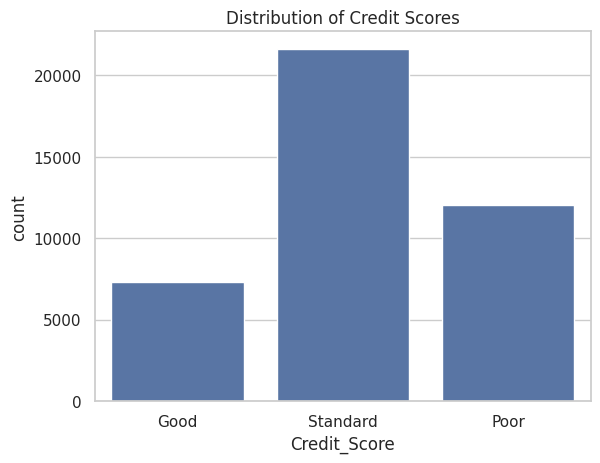

In [ ]:
#🔹 10. Exploratory Data Analysis (EDA)
#1. Credit Score Distribution
sns.countplot(x='Credit_Score', data=df)
plt.title("Distribution of Credit Scores")
plt.show()

#Observation:
#Most customers fall under Standard and Poor categories.




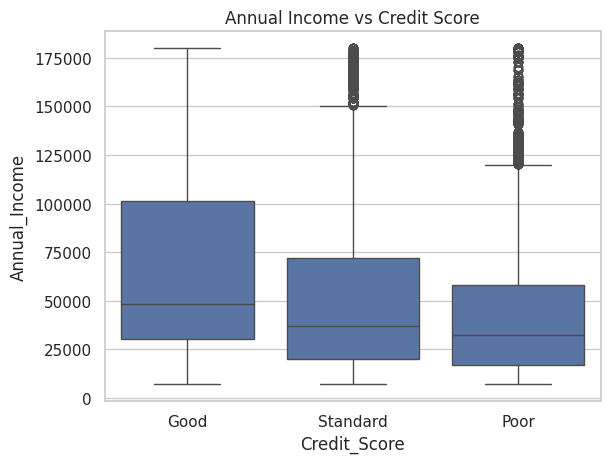

In [ ]:
#2. Annual Income vs Credit Score
sns.boxplot(x='Credit_Score', y='Annual_Income', data=df)
plt.title("Annual Income vs Credit Score")
plt.show()
#Observation:
#Higher credit scores generally correspond to higher income.


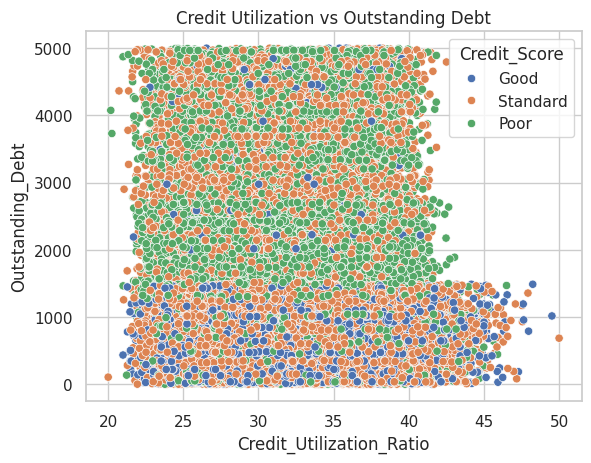

In [ ]:
#3. Credit Utilization vs Outstanding Debt
sns.scatterplot(
    x='Credit_Utilization_Ratio',
    y='Outstanding_Debt',
    hue='Credit_Score',
    data=df
)
plt.title("Credit Utilization vs Outstanding Debt")
plt.show()
#Observation:
#High utilization with high debt indicates poor credit behavior.


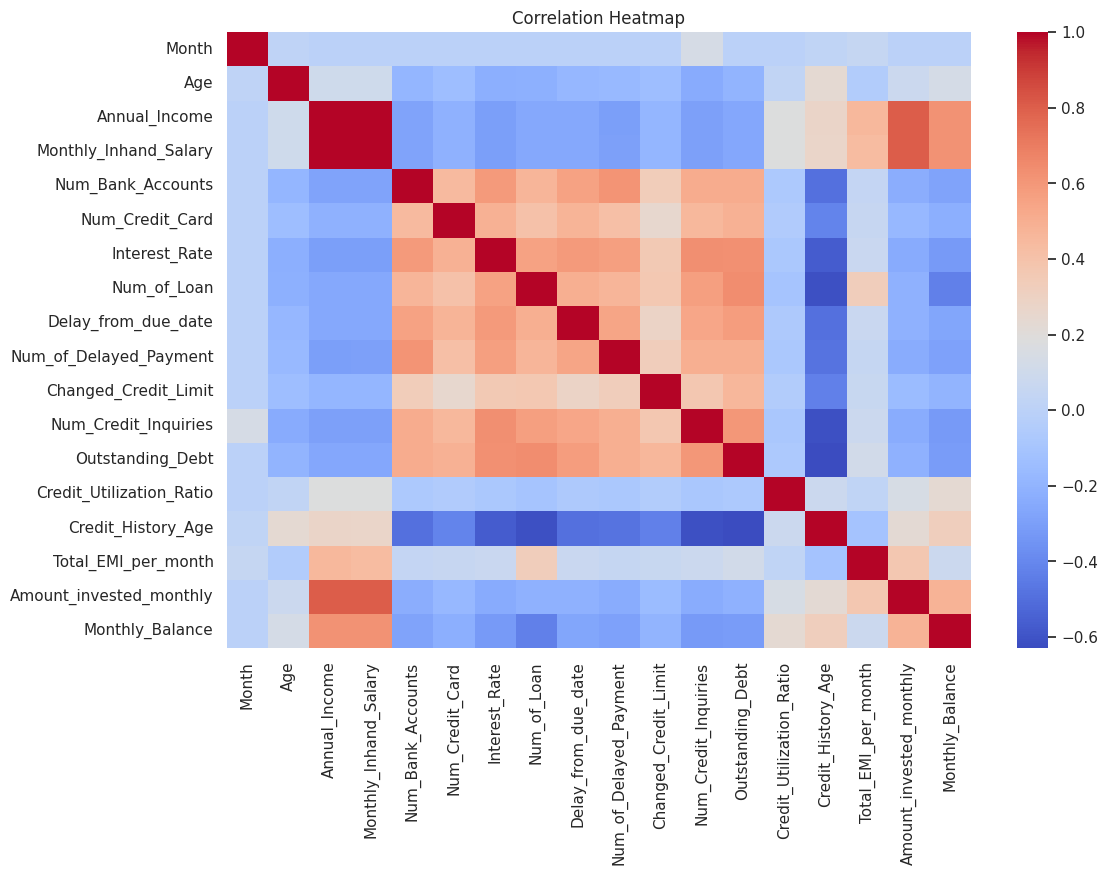

In [ ]:
#4. Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()
#Observation:
# Delayed payments and credit utilization show strong correlation with credit score.


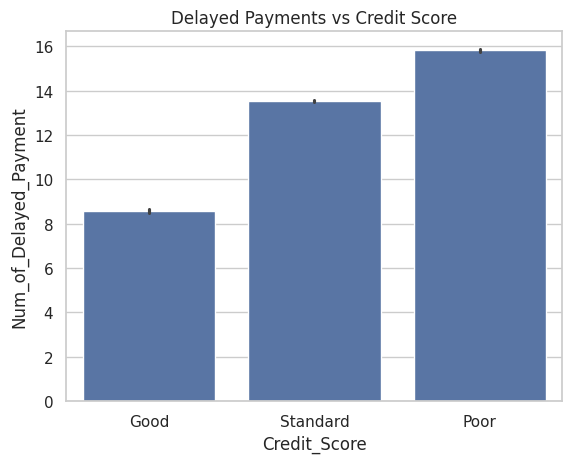

In [ ]:
# 5. Delayed Payments vs Credit Score
sns.barplot(
    x='Credit_Score',
    y='Num_of_Delayed_Payment',
    data=df
)
plt.title("Delayed Payments vs Credit Score")
plt.show()
#Observation:
#Poor credit score customers have significantly more delayed payments.

In [ ]:
# 11. Statistical Analysis
df.groupby('Credit_Score')[[
    'Annual_Income',
    'Credit_Utilization_Ratio',
    'Num_of_Delayed_Payment'
]].mean()


,Annual_Income,Credit_Utilization_Ratio,Num_of_Delayed_Payment
Credit_Score,,,
Good,65203.672105,32.686107,8.564842
Poor,40584.515325,31.986146,15.809883
Standard,50987.164840,32.313820,13.543518


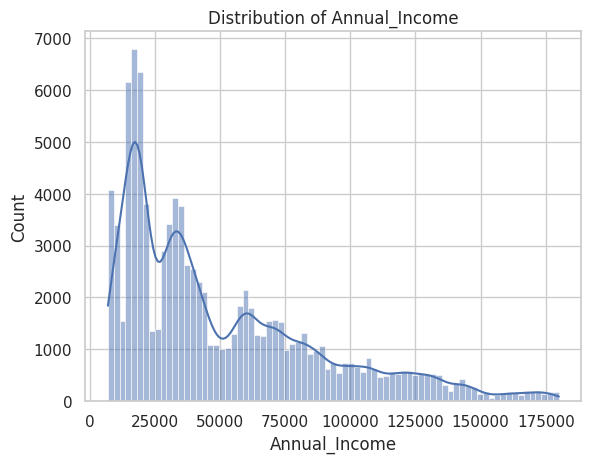

In [ ]:
def plot_distribution(column):
    sns.histplot(df[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.show()
plot_distribution('Annual_Income')


In [ ]:
#CONCLUSION
"""The exploratory data analysis reveals that credit score is influenced more by
payment behavior and credit usage patterns than income alone.

Key findings:
- Customers with fewer delayed payments consistently have higher credit scores
- Lower credit utilization ratios are associated with better creditworthiness
- A longer credit history positively impacts the credit score
- High outstanding debt combined with frequent delays indicates high default risk

Business Impact:
- Paisabazaar can use these insights to refine credit risk models
- Customers can be segmented for personalized loan and credit card recommendations
- Early warning indicators such as delayed payments can help prevent defaults

Overall, responsible credit usage and timely repayments are the strongest indicators
of a healthy credit profile."""